In [66]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import scipy.stats as stats
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


## Loading Data

In [3]:
# Load the dataset
df = pd.read_csv('../datasets/DB_data_2025-10.csv', sep=',')
df.sample(5)

,station_name,xml_station_name,eva,train_name,final_destination_station,delay_in_min,time,is_canceled,train_type,train_line_ride_id,train_line_station_num,arrival_planned_time,arrival_change_time,departure_planned_time,departure_change_time,id
906520,Paderborn Hbf,Paderborn Hbf,8000297,Bus EV,Hövelhof,0,2025-10-15 08:17:00,False,Bus,NaN,1,NaN,NaN,2025-10-15 08:17:00,2025-10-15 08:17:00,-1970341813916040056-2510150817-1
1679015,Köln Hbf,Köln Hbf,8000207,EC 9,Basel SBB,31,2025-10-27 11:24:00,False,EC,NaN,5,2025-10-27 10:46:00,2025-10-27 11:20:00,2025-10-27 10:53:00,2025-10-27 11:24:00,-8855626620852729650-2510270924-5
34826,Karlsruhe Hbf,Karlsruhe Hbf,8000191,RE 6,Karlsruhe Hbf,10,2025-10-01 14:04:00,False,RE,6.222585e+18,7,2025-10-01 13:54:00,2025-10-01 14:04:00,NaN,NaN,6222585272542646029-2510011305-7
21517,Berlin Potsdamer Platz,Berlin Potsdamer Platz,8011118,RE 4,Berlin Südkreuz,1,2025-10-01 10:08:00,False,RE,5.704185e+18,11,2025-10-01 10:05:00,2025-10-01 10:07:00,2025-10-01 10:07:00,2025-10-01 10:08:00,5704185483562774566-2510010846-11
85060,Bad Oldesloe,Bad Oldesloe,8000023,RE 80,Lübeck Hbf,0,2025-10-02 09:05:00,False,RE,NaN,3,2025-10-02 09:04:00,2025-10-02 09:03:00,2025-10-02 09:05:00,2025-10-02 09:05:00,-8807422335548759808-2510020834-3


## Data Inspection and Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989180 entries, 0 to 1989179
Data columns (total 16 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   station_name               object 
 1   xml_station_name           object 
 2   eva                        int64  
 3   train_name                 object 
 4   final_destination_station  object 
 5   delay_in_min               int64  
 6   time                       object 
 7   is_canceled                bool   
 8   train_type                 object 
 9   train_line_ride_id         float64
 10  train_line_station_num     int64  
 11  arrival_planned_time       object 
 12  arrival_change_time        object 
 13  departure_planned_time     object 
 14  departure_change_time      object 
 15  id                         object 
dtypes: bool(1), float64(1), int64(3), object(11)
memory usage: 229.5+ MB


In [5]:
# Create table

def format_example_values(series):
    vals = series.dropna().unique()[:5]
    
    formatted = []
    for v in vals:
        if isinstance(v, (int, float, np.number)):
            formatted.append(f"{v:.2f}")
        else:
            formatted.append(str(v))
    return ", ".join(formatted)

summary_df = pd.DataFrame({
    "Feature/variable": df.columns,
    "Data type": df.dtypes.values.astype(str),
    "Number of Unique values": [df[col].nunique() for col in df.columns],
    "Missing values": [df[col].isna().sum() for col in df.columns],
    "Example values": [format_example_values(df[col]) for col in df.columns]
    
})

# Show all rows without truncation
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    print(summary_df.to_markdown(index=False))

| Feature/variable          | Data type   |   Number of Unique values |   Missing values | Example values                                                                                                                                                            |
|:--------------------------|:------------|--------------------------:|-----------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| station_name              | object      |                       107 |                0 | Hamburg Hbf, München Ost, Köln Hbf, Stuttgart Hbf, Duisburg Hbf                                                                                                           |
| xml_station_name          | object      |                       130 |                0 | Hamburg Hbf, München Ost, Köln Hbf, Stuttgart Hbf, Duisburg Hbf                                                         

In [6]:
# Create table for numeric columns
numeric_cols = ["delay_in_min"]

# Basic descriptive statistics
desc = df[numeric_cols].describe().rename(index={
    "50%": "50%",
    "25%": "25%",
    "75%": "75%"
})

# Add variance
desc.loc["Variance"] = df[numeric_cols].var()

# Add dispersion index = variance / mean
dispersion_index = df[numeric_cols].var() / df[numeric_cols].mean()
desc.loc["Dispersion index (Variance / Mean)"] = dispersion_index

# Reorder rows 
row_order = [
    "count", "mean", "std", "min", "25%", "50%", "75%", "max",
    "Variance", "Dispersion index (Variance / Mean)"
]
desc = desc.loc[row_order]

# Convert to Markdown
md_table = desc.to_markdown(tablefmt="pipe", floatfmt=".2f")
print(md_table)

|                                    |   delay_in_min |
|:-----------------------------------|---------------:|
| count                              |     1989180.00 |
| mean                               |           4.89 |
| std                                |          10.95 |
| min                                |       -1435.00 |
| 25%                                |           0.00 |
| 50%                                |           1.00 |
| 75%                                |           5.00 |
| max                                |         386.00 |
| Variance                           |         119.79 |
| Dispersion index (Variance / Mean) |          24.50 |


In [7]:
# Descriptive table for categorical variables

categorical_cols = df.select_dtypes(include=['object']).columns
cat_desc = pd.DataFrame(index=categorical_cols, columns=[
    "Unique Values"
])

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    most_freq_val = counts.idxmax()
    freq = counts.max()
    perc = freq / counts.sum() * 100

    cat_desc.loc[col] = [
        df[col].nunique()
    ]

# Convert to Markdown
md_table_cat = cat_desc.to_markdown(tablefmt="pipe", floatfmt=".2f")
print(md_table_cat)

|                           |   Unique Values |
|:--------------------------|----------------:|
| station_name              |             107 |
| xml_station_name          |             130 |
| train_name                |            1573 |
| final_destination_station |            1353 |
| time                      |           44530 |
| train_type                |              55 |
| arrival_planned_time      |           44338 |
| arrival_change_time       |           44365 |
| departure_planned_time    |           44353 |
| departure_change_time     |           44354 |
| id                        |         1989180 |


In [8]:
# check mising values
missing_counts = df.isna().sum()
print(missing_counts)

station_name                      0
xml_station_name                  0
eva                               0
train_name                        0
final_destination_station         0
delay_in_min                      0
time                              0
is_canceled                       0
train_type                        0
train_line_ride_id           988616
train_line_station_num            0
arrival_planned_time         446738
arrival_change_time          446699
departure_planned_time       445857
departure_change_time        445805
id                                0
dtype: int64


In [9]:
# check for duplicates 
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [10]:
# delete duplicates
df.drop_duplicates(inplace=True)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [11]:
# compare all values in station_name and xml_station_name and output the differences

station_names = set(df["station_name"].unique())
xml_station_names = set(df["xml_station_name"].unique())
differences = station_names.symmetric_difference(xml_station_names)
print("Values in station_name but not in xml_station_name:", station_names - xml_station_names)
print("Values in xml_station_name but not in station_name:", xml_station_names - station_names)

Values in station_name but not in xml_station_name: {'Freiburg (Breisgau) Hbf', 'Berlin Hauptbahnhof', 'Frankfurt (Main) Hbf', 'Landshut (Bay) Hbf', 'Neustadt (Weinstr) Hbf', 'Halle (Saale) Hbf', 'Singen (Hohentwiel)', 'Fürth (Bay) Hbf', 'Frankfurt (Oder)', 'Münster (Westf) Hbf', 'Frankfurt (Main) Süd', 'Hamm (Westf) Hbf', 'Oldenburg (Oldb) Hbf', 'Ludwigshafen (Rhein) Hbf'}
Values in xml_station_name but not in station_name: {'Hamburg-Altona(S)', 'Potsdam Hbf (S)', 'Berlin Gesundbrunnen(S)', 'Fürth(Bay)Hbf', 'Berlin Friedrichstraße (S)', 'Berlin-Wannsee (S)', 'Frankfurt(Main)Hbf', 'Flughafen BER (S-Bahn)', 'Frankfurt(Main)Süd', 'Hamburg Hbf (S-Bahn)', 'Halle(Saale)Hbf', 'Köln Messe/Deutz Gl.11-12', 'Oldenburg(Oldb)Hbf', 'München Hbf (tief)', 'Frankfurt Hbf (tief)', 'Münster(Westf)Hbf', 'Hamburg-Harburg(S)', 'Singen(Hohentwiel)', 'Berlin-Spandau (S)', 'Berlin Potsdamer Platz (S)', 'Berlin Ostkreuz (S)', 'Stuttgart Hbf (tief)', 'München Hbf Gl.5-10', 'Neustadt(Weinstr)Hbf', 'Leipzig Hbf 

Since station_name column has more clean data, while xml_station_name has some irrelevant data ( duplicates, platform numbers etc.), it is decided to use station_name in analysis.

In [12]:
# Drop extra columns

df.drop(columns=["id", "xml_station_name", "eva", "train_line_ride_id"], inplace=True)


Since destination_name has many unique values, we check for possible duplicates and misspellings

In [13]:
# Create a new column for cleaned destination, remove spaces and dashes
df["cleaned_destination"] = (df["final_destination_station"]
.str.replace(" ", "", regex=False)
.str.replace("-", "", regex=False))

# Remove the S-Bahn marker
df["cleaned_destination"] = (df["cleaned_destination"]
.str.replace("(S)", "", regex=False)
.str.replace("(s)", "", regex=False))

# Fix specific duplicates, swap "(Rh)" for "(Rhein)"
df["cleaned_destination"] = (df["cleaned_destination"]
.str.replace("Terminal", "", regex=False)
.str.replace("(Rh)", "(Rhein)", regex=False))

# Remove "Gl." and track numbers
df["cleaned_destination"] = df["cleaned_destination"].str.replace(r"Gl\.\d*", "", regex=True)

# Print the new number of values
new_unique_count = df["cleaned_destination"].nunique()
print("New number of unique stations:", new_unique_count)

# Insert cleaned column
cleaned_column_data = df.pop("cleaned_destination")
insert_position = df.columns.get_loc("final_destination_station")
df.insert(insert_position, "cleaned_destination", cleaned_column_data)

New number of unique stations: 1320


In [14]:
# Check that there are no rows with both times of arrival and departure missing

missing_both_count = (df["arrival_planned_time"].isna() & df["departure_planned_time"].isna()).sum()
print("Number of rows missing both arrival and departure:", missing_both_count)

Number of rows missing both arrival and departure: 0


In [ ]:
# Detect outliers in delay_in_min
s = df["delay_in_min"].dropna()

summary = s.describe(percentiles=[.001, .01, .05, .5, .95, .99, .999])
neg_rate = (s < 0).mean()
summary, neg_rate, s.min(), s.max()

(count    1.989125e+06
 mean     4.894842e+00
 std      1.084463e+01
 min     -5.900000e+01
 0.1%    -5.000000e+00
 1%      -1.000000e+00
 5%       0.000000e+00
 50%      1.000000e+00
 95%      2.200000e+01
 99%      5.200000e+01
 99.9%    1.170000e+02
 max      3.860000e+02
 Name: delay_in_min, dtype: float64,
 np.float64(0.01987004336077421),
 -59,
 386)

In [26]:
# Drop outliers (large negative values likely represent data errors)
df = df[df["delay_in_min"] > -60]

In [27]:
df

,station_name,train_name,cleaned_destination,final_destination_station,delay_in_min,time,is_canceled,train_type,train_line_station_num,arrival_planned_time,arrival_change_time,departure_planned_time,departure_change_time
0,Hamburg Hbf,ME RB41,HamburgHbf,Hamburg Hbf,34,2025-10-01 00:00:00,False,ME,15,2025-09-30 23:26:00,2025-10-01 00:00:00,NaN,NaN
1,München Ost,S 1,Freising,Freising,7,2025-10-01 00:00:00,False,S,2,2025-09-30 23:52:00,2025-09-30 23:56:00,2025-09-30 23:53:00,2025-10-01 00:00:00
2,Köln Hbf,S 11,Norf,Norf,16,2025-10-01 00:00:00,True,S,8,2025-09-30 23:43:00,2025-10-01 00:25:00,2025-09-30 23:44:00,2025-10-01 00:00:00
3,Stuttgart Hbf,RE 8,StuttgartHbf,Stuttgart Hbf,8,2025-10-01 00:00:00,False,RE,5,2025-09-30 23:52:00,2025-10-01 00:00:00,NaN,NaN
4,Duisburg Hbf,RE 3,DüsseldorfHbf,Düsseldorf Hbf,7,2025-10-01 00:00:00,False,RE,9,2025-09-30 23:50:00,2025-10-01 00:00:00,2025-09-30 23:53:00,2025-10-01 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989175,Berlin-Spandau,RE 4,BerlinHbf,Berlin Hbf,7,2025-10-31 23:59:00,False,RE,9,2025-10-31 23:50:00,2025-10-31 23:57:00,2025-10-31 23:52:00,2025-10-31 23:59:00
1989176,Köln Messe/Deutz,RB 25,Gummersbach,Gummersbach,2,2025-10-31 23:59:00,False,RB,3,2025-10-31 23:56:00,2025-10-31 23:58:00,2025-10-31 23:57:00,2025-10-31 23:59:00
1989177,Bietigheim-Bissingen,MEX 18,BietigheimBissingen,Bietigheim-Bissingen,1,2025-10-31 23:59:00,False,MEX,13,2025-10-31 23:58:00,2025-10-31 23:59:00,NaN,NaN
1989178,Bielefeld Hbf,NWB RB75,BielefeldHbf,Bielefeld Hbf,6,2025-10-31 23:59:00,False,NWB,19,2025-10-31 23:53:00,2025-10-31 23:59:00,NaN,NaN


# How much of the variation in train delay duration can be explained by observable operational and structural factors, and what are the limits of predictability?

In [28]:
# Create a clean copy for modeling
df_clean = df.copy()

In [ ]:
# Clip small negative values to zero, as they likely represent early arrivals, 
# and we want to focus on delay duration
df_clean["delay_model"] = df_clean["delay_in_min"].clip(lower=0)

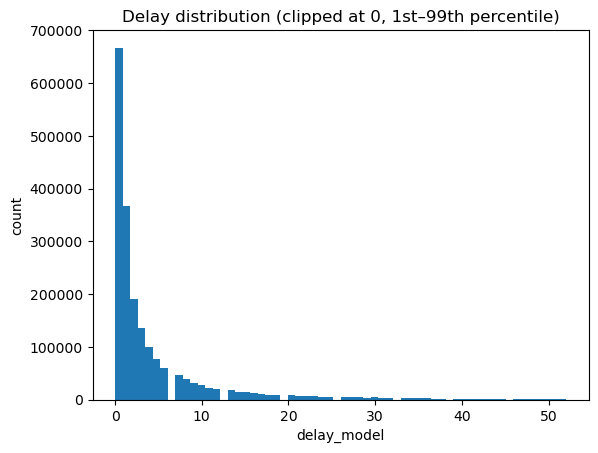

(0.0, 52.0)

In [30]:
df_clean = df[df["delay_in_min"] > -60].copy()
df_clean["delay_model"] = df_clean["delay_in_min"].clip(lower=0)

s = df_clean["delay_model"]

lo, hi = s.quantile([0.01, 0.99])

plt.figure()
plt.hist(s[(s >= lo) & (s <= hi)], bins=60)
plt.title("Delay distribution (clipped at 0, 1st–99th percentile)")
plt.xlabel("delay_model")
plt.ylabel("count")
plt.show()

lo, hi


Interpretation: 
At 0:
- Large spike: Many trains are exactly on time (or early and clipped to 0)
- Zero Heavy

After zero:
- Rapid decay
- Long tail extending beyond 50 minutes
- Most delays are small (< 10 min)

Implies:
1. Normality assumption is clearly violated.
2. Variance increases with mean.
3. OLS residuals will likely be heteroskedastic.

In [31]:
# Create log target
df_clean["log_delay"] = np.log1p(df_clean["delay_model"])

In [37]:
# Convert planned times to datetime, coerce errors to NaT
df_clean["departure_planned_time"] = pd.to_datetime(
    df_clean["departure_planned_time"],
    errors="coerce"
)

# Drop rows with invalid planned departure times using .loc to avoid SettingWithCopyWarning
df_clean = df_clean.loc[df_clean["departure_planned_time"].notna()]

# Create features from planned departure time
df_clean["dep_hour"] = df_clean["departure_planned_time"].dt.hour
df_clean["dep_dow"] = df_clean["departure_planned_time"].dt.dayofweek
df_clean["dep_month"] = df_clean["departure_planned_time"].dt.month
df_clean["is_weekend"] = (df_clean["dep_dow"] >= 5).astype(int)

df_clean[["dep_hour","dep_dow","dep_month","is_weekend"]].head()

/var/folders/x_/zccbsk657rb51hx1tc0t1ss80000gn/T/ipykernel_82294/3436791749.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["departure_planned_time"] = pd.to_datetime(


,dep_hour,dep_dow,dep_month,is_weekend
1,23,1,9,0
2,23,1,9,0
4,23,1,9,0
5,23,1,9,0
7,0,2,10,0


In [39]:
# Recreate log target
df_clean["delay_model"] = df_clean["delay_in_min"].clip(lower=0)
df_clean["log_delay"] = np.log1p(df_clean["delay_model"])

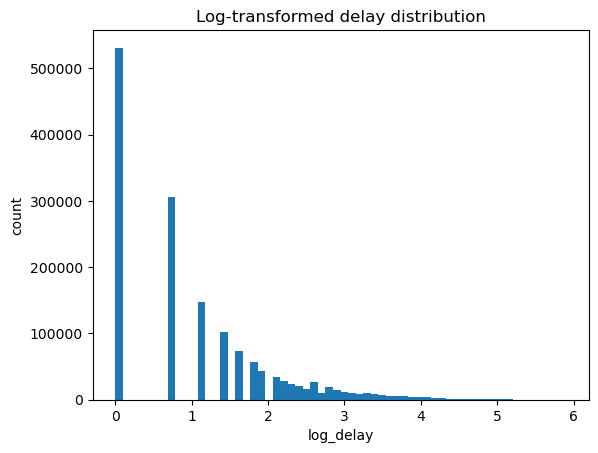

In [89]:
# Plot histogram of log delay
plt.figure()
plt.hist(df_clean["log_delay"], bins=60)
plt.title("Log-transformed delay distribution")
plt.xlabel("log_delay")
plt.ylabel("count")
plt.show()

In [41]:
# Define a minimal first model of numeric variables to diagnose assumptions 
# and understand the data better
features_num = [
    "train_line_station_num",
    "dep_hour",
    "dep_dow",
    "dep_month",
    "is_weekend"
]

df_diag = df_clean[features_num + ["log_delay"]].dropna()
df_diag.shape


(1543292, 6)

In [ ]:
# Split into train and test sets
X = df_diag[features_num]
y = df_diag["log_delay"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Fit the log linear model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

In [50]:
# Print performance metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

r2, rmse, mae

(0.04146507838798574, np.float64(1.022346839231538), 0.8290993068872428)

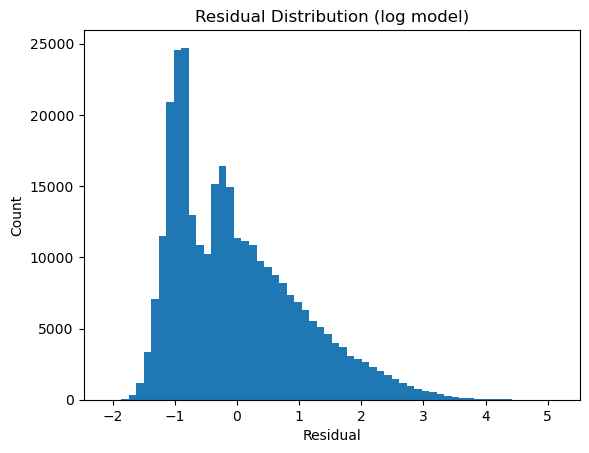

In [ ]:
# Residual histogram
plt.figure()
plt.hist(residuals, bins=60)
plt.title("Residual Distribution (log model)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

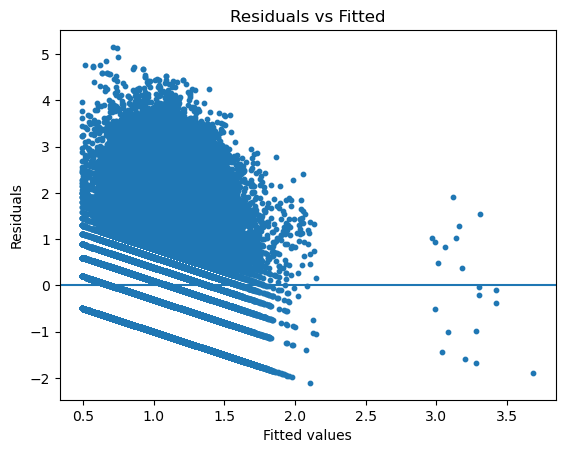

In [52]:
# Residuals vs. fitted values
plt.figure()
plt.scatter(y_pred, residuals, s=10)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

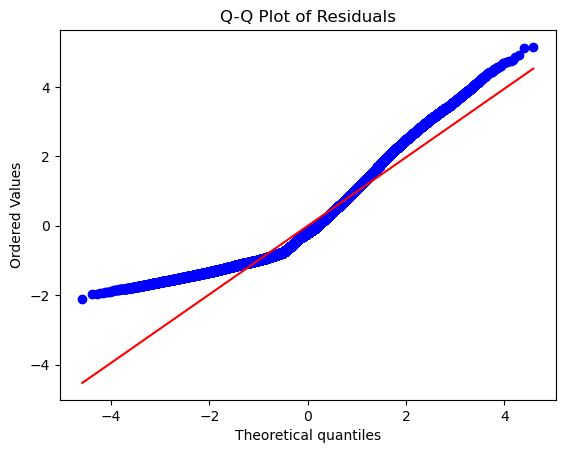

In [ ]:
# QQ plot of residuals
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Log-Transformed Regression: Summary
- Target variable defined as log(1+delay) to address strong right-skewness and zero-heavy distribution.
- Baseline model (operational + positional variables only) explains ~4% of variance (R² ≈ 0.04).
- Residuals are still slightly right-skewed but improved
- Some heteroskedasticity remains, though not severe given the large sample size.
- Normality is not perfectly satisfied in the tails, which is expected for heavy-tailed delay data.
- Overall, simple temporal and line-position variables explain only a small share of delay variation. In the next step, we include structural factors (e.g., train type and station) to evaluate how much additional variation can be explained and to better assess the limits of predictability.

In [ ]:
# Check unique values in station_name, train_type, and cleaned_destination
df_clean["station_name"].nunique()
df_clean["train_type"].nunique()
df_clean["cleaned_destination"].nunique()

print(f"Unique stations: {df_clean['station_name'].nunique()}")
print(f"Unique train types: {df_clean['train_type'].nunique()}")
print(f"Unique cleaned destinations: {df_clean['cleaned_destination'].nunique()}")

Unique stations: 107
Unique train types: 55
Unique cleaned destinations: 1319


In [58]:
# Numeric features
num_cols = [
    "train_line_station_num",
    "dep_hour",
    "dep_dow",
    "dep_month",
    "is_weekend"
]

# Categorical features for Model 2
cat_cols_m2 = ["train_type"]

# Categorical features for Model 3
cat_cols_m3 = ["train_type", "station_name"]

In [59]:
df_model = df_clean[num_cols + ["train_type", "station_name", "log_delay"]].dropna()

X = df_model[num_cols + ["train_type", "station_name"]]
y = df_model["log_delay"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
preprocess_m2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_m2),
        ("num", "passthrough", num_cols)
    ]
)

model_m2 = Pipeline([
    ("preprocess", preprocess_m2),
    ("ridge", Ridge(alpha=1.0))
])

model_m2.fit(X_train, y_train)
pred_m2 = model_m2.predict(X_test)

r2_m2 = r2_score(y_test, pred_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test, pred_m2))

r2_m2, rmse_m2

(0.15744847613519652, np.float64(0.9585008953872))

In [61]:
preprocess_m3 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_m3),
        ("num", "passthrough", num_cols)
    ]
)

model_m3 = Pipeline([
    ("preprocess", preprocess_m3),
    ("ridge", Ridge(alpha=1.0))
])

model_m3.fit(X_train, y_train)
pred_m3 = model_m3.predict(X_test)

r2_m3 = r2_score(y_test, pred_m3)
rmse_m3 = np.sqrt(mean_squared_error(y_test, pred_m3))

r2_m3, rmse_m3

(0.20991621346818645, np.float64(0.9281771304198027))

In [82]:
# Predictions from final Ridge model
pred_ridge_log = model_m3.predict(X_test)

# Residuals
res_ridge = y_test - pred_ridge_log

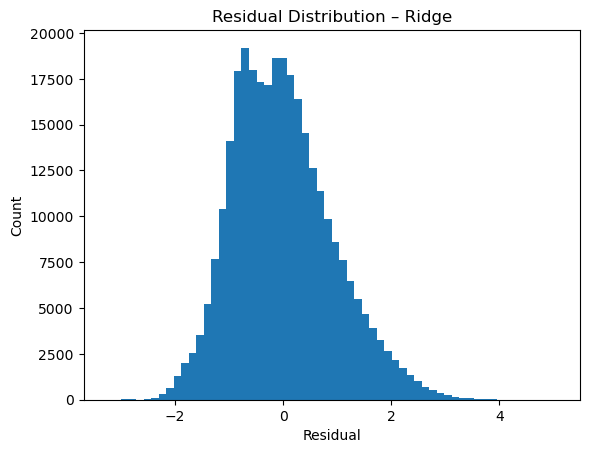

In [84]:
# Residuals
plt.figure()
plt.hist(res_ridge, bins=60)
plt.title("Residual Distribution – Ridge")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

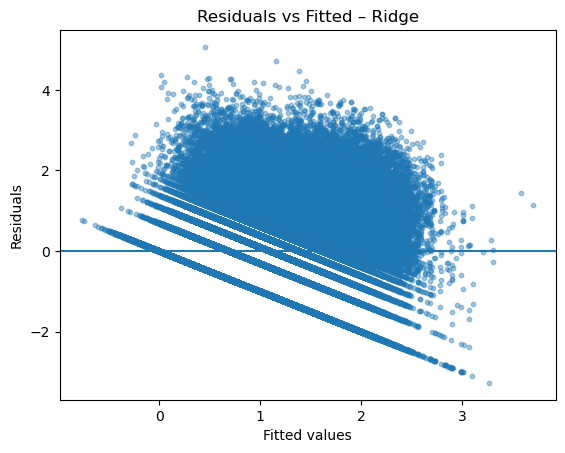

In [85]:
plt.figure()
plt.scatter(pred_ridge_log, res_ridge, s=10, alpha=0.4)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted – Ridge")
plt.show()

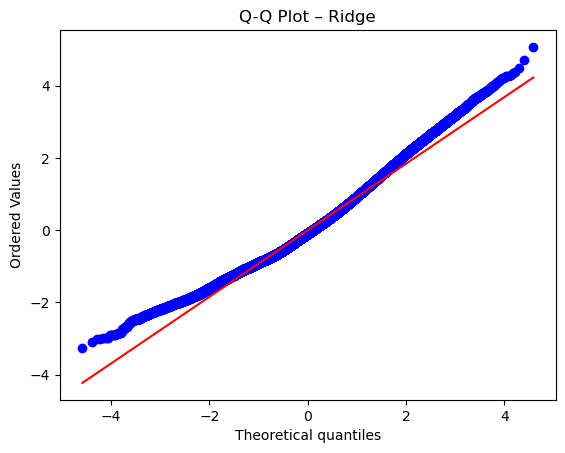

In [87]:
# QQ Plot
plt.figure()
stats.probplot(res_ridge, dist="norm", plot=plt)
plt.title("Q-Q Plot – Ridge")
plt.show()

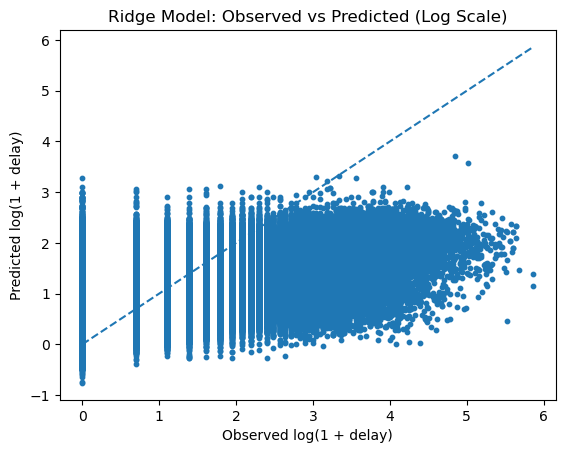

In [73]:
plt.figure()
plt.scatter(y_test, model_m3.predict(X_test), s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Observed log(1 + delay)")
plt.ylabel("Predicted log(1 + delay)")
plt.title("Ridge Model: Observed vs Predicted (Log Scale)")
plt.show()

Incremental Model Comparison

- Operational variables alone explain ~4% of delay variation.
- Adding train type increases explanatory power substantially (R² ≈ 0.16).
- Including station identity further improves the model (R² ≈ 0.21).
- Structural characteristics therefore play a significantly larger role than basic scheduling variables. However, even the most comprehensive model explains only about one fifth of delay variation, indicating substantial inherent unpredictability and the likely importance of unobserved operational and environmental factors.

**Are delays nonlinear and can a flexible model substantially improve predictability?**

In [64]:
# Run a Random Forest benchmark to see if nonlinearity significantly improves R².
# Create subsample for computational efficiency
df_sample = df_model.sample(n=400_000, random_state=42)

X_sample = df_sample[num_cols + ["train_type", "station_name"]]
y_sample = df_sample["log_delay"]

from sklearn.model_selection import train_test_split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)


In [65]:
# Run on smaller sample for speed
rf_model = Pipeline([
    ("preprocess", preprocess_rf),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,        # limit depth for speed + regularization
        n_jobs=-1,
        random_state=42
    ))
])

rf_model.fit(X_train_s, y_train_s)

pred_rf = rf_model.predict(X_test_s)

r2_rf = r2_score(y_test_s, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_s, pred_rf))

r2_rf, rmse_rf

(0.25611929708257664, np.float64(0.9017651630874651))

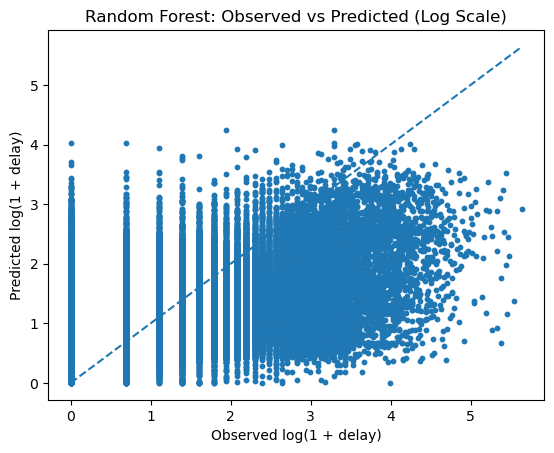

In [74]:
plt.figure()
plt.scatter(y_test_s, pred_rf, s=10)
plt.plot([y_test_s.min(), y_test_s.max()],
         [y_test_s.min(), y_test_s.max()],
         linestyle="--")
plt.xlabel("Observed log(1 + delay)")
plt.ylabel("Predicted log(1 + delay)")
plt.title("Random Forest: Observed vs Predicted (Log Scale)")
plt.show()

In [75]:
res_ridge = y_test - model_m3.predict(X_test)
res_rf = y_test_s - pred_rf

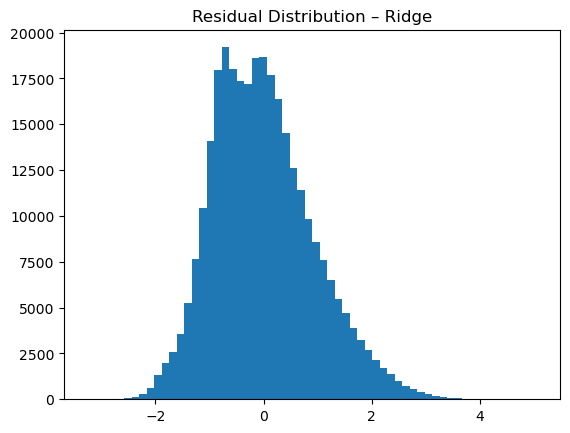

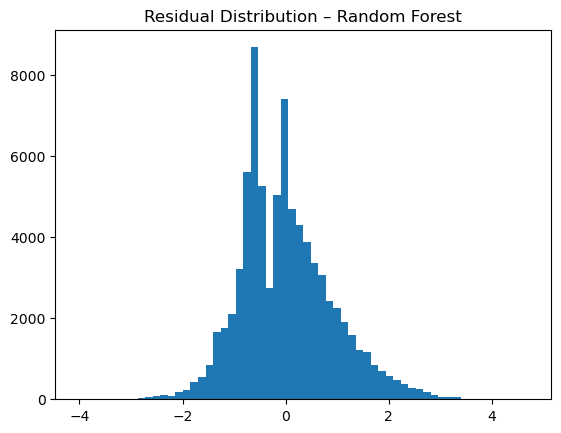

In [90]:
# Side by side comparison
plt.figure()
plt.hist(res_ridge, bins=60)
plt.title("Residual Distribution – Ridge")
plt.show()

plt.figure()
plt.hist(res_rf, bins=60)
plt.title("Residual Distribution – Random Forest")
plt.show()

In [91]:
# Back to minutes
# Ridge
pred_ridge_minutes = np.expm1(model_m3.predict(X_test))
true_minutes = np.expm1(y_test)

# RF
pred_rf_minutes = np.expm1(pred_rf)
true_rf_minutes = np.expm1(y_test_s)

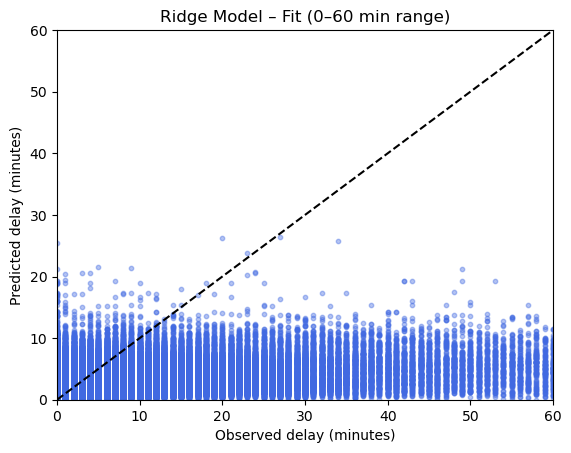

In [ ]:
# Ridge model fit in minutes
plt.figure()
plt.scatter(true_minutes, pred_ridge_minutes,
            s=10, alpha=0.4, color="royalblue")

plt.plot([0, 60],
         [0, 60],
         linestyle="--",
         color="black")

plt.xlim(0, 60)
plt.ylim(0, 60)

plt.xlabel("Observed delay (minutes)")
plt.ylabel("Predicted delay (minutes)")
plt.title("Ridge Model – Fit (0–60 min range)")
plt.show()

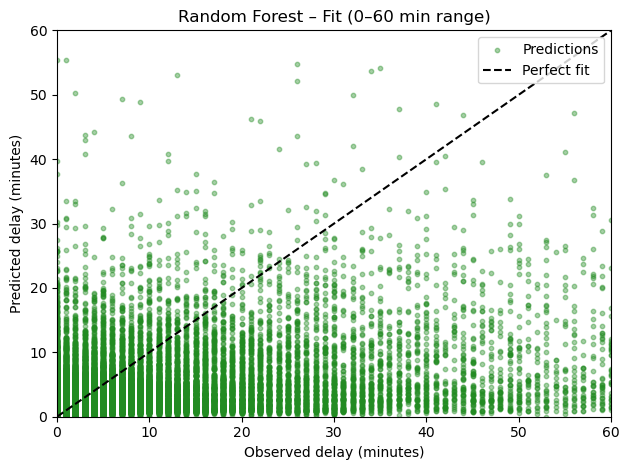

In [ ]:
# RF model fit in minutes
plt.figure()

plt.scatter(true_rf_minutes, pred_rf_minutes,
            s=10,
            alpha=0.4,
            color="forestgreen",
            label="Predictions")

plt.plot([0, 60],
         [0, 60],
         linestyle="--",
         color="black",
         label="Perfect fit")

plt.xlim(0, 60)
plt.ylim(0, 60)

plt.xlabel("Observed delay (minutes)")
plt.ylabel("Predicted delay (minutes)")
plt.title("Random Forest – Fit (0–60 min range)")
plt.legend()
plt.tight_layout()
plt.show()

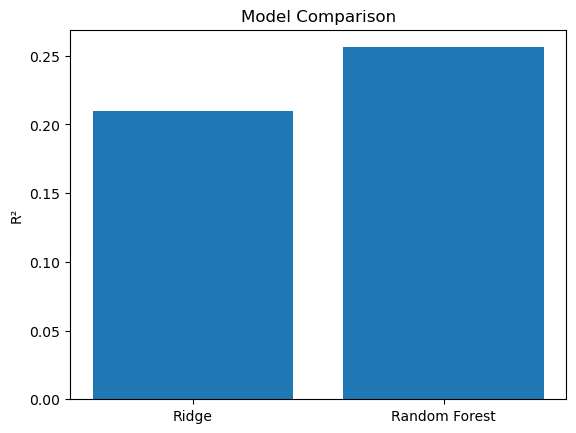

In [81]:
# Model comparison summary
models = ["Ridge", "Random Forest"]
r2_vals = [r2_m3, r2_rf]

plt.figure()
plt.bar(models, r2_vals)
plt.ylabel("R²")
plt.title("Model Comparison")
plt.show()

The Random Forest model increases explanatory power to R² ≈ 0.26, compared to 0.21 in the linear Ridge model. This indicates that there are nonlinear relationships and interactions between structural and operational variables. However, even flexible nonlinear modeling explains only about one quarter of total variation in delay duration. This suggests that while delays exhibit structural patterns, a high proportion of variability remains driven by unobserved or stochastic factors, which indicates that there are clear limits to predictability within the available data, and factors such as weather shocks, infrastructure disruptions, network propagation effects, incident randomness, etc. likely play an important role in predicting train delays.

In [ ]:
# permutation importance on original input features
result = permutation_importance(
    rf_model,
    X_test_s,
    y_test_s,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    result.importances_mean,
    index=X_test_s.columns
).sort_values(ascending=False)

importances

train_type                0.317631
train_line_station_num    0.234985
station_name              0.127681
dep_hour                  0.059419
is_weekend                0.010559
dep_dow                   0.009617
dep_month                 0.000017
dtype: float64

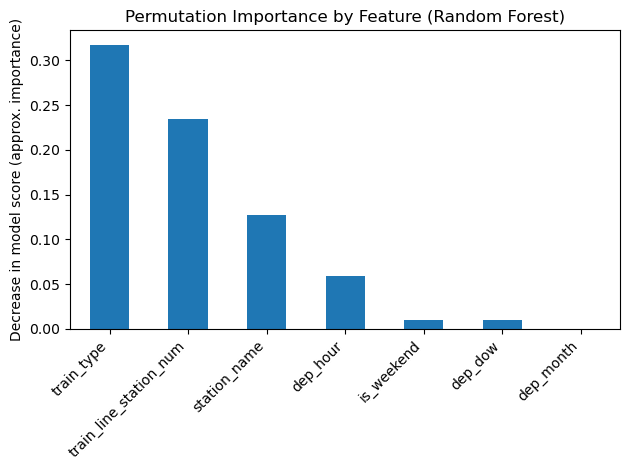

In [ ]:
# Plot feature importance
plt.figure()
importances.plot(kind="bar")
plt.title("Permutation Importance by Feature (Random Forest)")
plt.ylabel("Decrease in model score (approx. importance)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()